
Logistic Regression
Accuracy: 0.833
Precision: 0.875
Recall: 0.750
F1: 0.808
ROC-AUC: 0.919

Decision Tree
Accuracy: 0.783
Precision: 0.800
Recall: 0.714
F1: 0.755
ROC-AUC: 0.779

Random Forest
Accuracy: 0.833
Precision: 0.846
Recall: 0.786
F1: 0.815
ROC-AUC: 0.914

SVM (RBF)
Accuracy: 0.850
Precision: 0.852
Recall: 0.821
F1: 0.836
ROC-AUC: 0.938


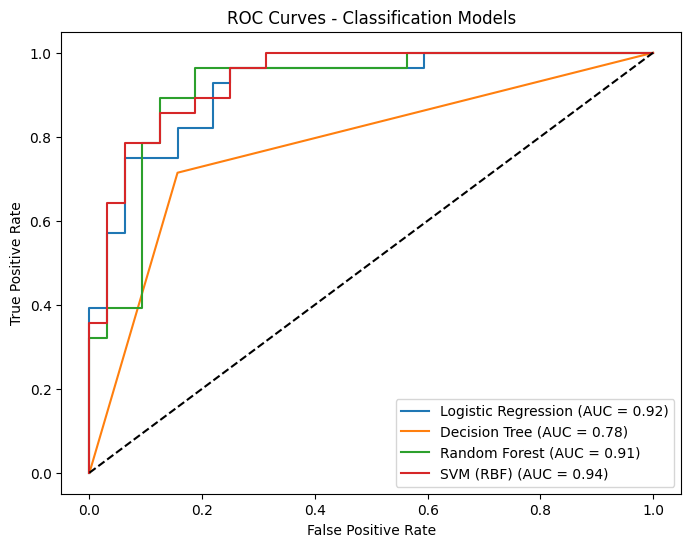

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_reduced, test_size=0.2, random_state=42, stratify=y_reduced
)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="liblinear"),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM (RBF)": SVC(probability=True, kernel="rbf", random_state=42)
}

results = {}

# Train & evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

    # Print metrics
    print(f"\n{name}")
    for metric, score in results[name].items():
        print(f"{metric}: {score:.3f}")

# ✅ ROC Curve Plot
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Classification Models")
plt.legend()
plt.show()
